# Phase 4 — Cost-sensitive thresholding + explainability

Goal: replace the arbitrary 0.5 threshold with one that minimizes actual business cost, and explain individual flagged transactions with SHAP.

This notebook goes back to the **real, undrifted** day-1/day-2 split and static XGBoost model from Phase 2 — Phase 3's synthetic drift injection was only for demonstrating the drift-detection mechanism, and mixing it in here would muddy a cost analysis that should reflect the real data.

**Cost-sensitive thresholding, plain English:** every threshold trades off two error types differently — missing real fraud (false negative) vs. wrongly flagging a legit transaction (false positive). These don't cost the same in practice. If we assign each an explicit cost, we can compute the *expected total cost* at every threshold and pick the one that minimizes it, instead of defaulting to 0.5, which has no business meaning at all.

**Cost matrix used here (illustrative, not derived from real business data):** missed fraud = 100 cost units, false alarm = 1 cost unit — a 100:1 ratio, kept as abstract units since the dataset doesn't specify a currency.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw
from src.features import FEATURE_COLS, add_hour
from src.models import fit_xgboost, xgboost_scores

df = add_hour(load_raw())
train_df = df[df['Hour'] < 24].reset_index(drop=True)
test_df = df[df['Hour'] >= 24].reset_index(drop=True)

X_train, y_train = train_df[FEATURE_COLS], train_df['Class']
X_test, y_test = test_df[FEATURE_COLS], test_df['Class']

model = fit_xgboost(X_train, y_train)
test_df['score'] = xgboost_scores(model, X_test)

print('model re-trained on day 1, scored', len(test_df), 'day-2 transactions')

model re-trained on day 1, scored 140021 day-2 transactions


## Sweep thresholds, find the cost-minimizing one

In [2]:
from src.cost import sweep_thresholds, find_optimal_threshold

COST_FN = 100  # missed fraud
COST_FP = 1    # false alarm

best_threshold, sweep = find_optimal_threshold(y_test, test_df['score'], COST_FN, COST_FP)
min_cost = sweep['cost'].min()
default_cost = sweep.loc[np.isclose(sweep['threshold'], 0.5, atol=0.01), 'cost'].iloc[0]

print(f'cost-minimizing threshold: {best_threshold:.2f}')
print(f'expected cost at that threshold: {min_cost}')
print(f'expected cost at default 0.5 threshold: {default_cost}')

cost-minimizing threshold: 0.19
expected cost at that threshold: 3507
expected cost at default 0.5 threshold: 4034


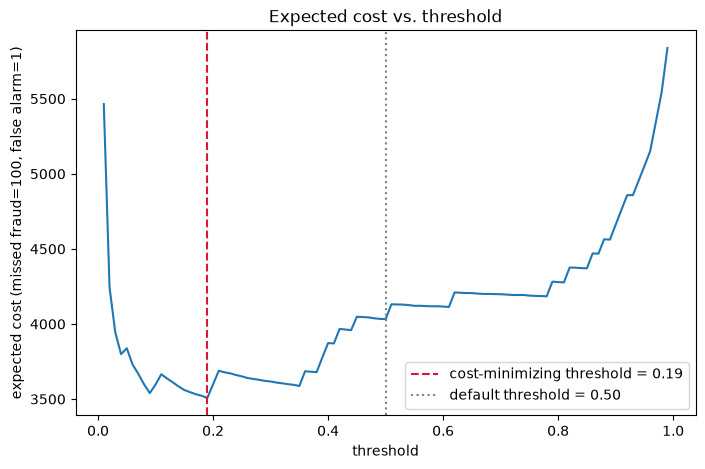

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep['threshold'], sweep['cost'])
ax.axvline(best_threshold, color='crimson', linestyle='--', label=f'cost-minimizing threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='default threshold = 0.50')
ax.set_xlabel('threshold')
ax.set_ylabel(f'expected cost (missed fraud={COST_FN}, false alarm={COST_FP})')
ax.set_title('Expected cost vs. threshold')
ax.legend()
plt.show()

**Result:** cost-minimizing threshold = 0.19 (vs. the default 0.5), cutting expected cost from 4,034 to 3,507 (13% lower). This makes sense given the 100:1 cost ratio: missing fraud is so much more expensive than a false alarm that the optimal policy flags more aggressively — accepting more false alarms — than a "confidence >= 50%" rule would.

Let's see what this actually looks like in raw counts.

In [4]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

for label, t in [('default (0.50)', 0.5), ('cost-minimizing', best_threshold)]:
    preds = (test_df['score'] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    print(f'{label} threshold={t:.2f}: TP={tp} FP={fp} FN={fn} TN={tn} | precision={precision:.3f} recall={recall:.3f}')

default (0.50) threshold=0.50: TP=172 FP=132 FN=39 TN=139678 | precision=0.566 recall=0.815
cost-minimizing threshold=0.19: TP=179 FP=307 FN=32 TN=139503 | precision=0.368 recall=0.848


**Result:** at the cost-minimizing threshold, we catch 179/211 frauds (84.8% recall, up from 81.5%) at the cost of more false alarms (307 vs. 132, precision drops from 56.6% to 36.8%). That's exactly the intended tradeoff: with false alarms 100x cheaper than missed fraud, it's worth accepting many more of them to catch a few more real frauds.

## SHAP explanations for individual alerts

So far we can say a transaction was flagged, but not *why*. SHAP (SHapley Additive exPlanations) answers that per-transaction: for each flagged transaction, it breaks down the model's prediction into how much each feature pushed the score up or down from a baseline. We'll explain 3 transactions the cost-optimal threshold actually flags as fraud.

In [5]:
from src.explain import build_explainer, explain, top_contributions

explainer = build_explainer(model)

flagged_true_positives = test_df[(test_df['score'] >= best_threshold) & (test_df['Class'] == 1)]
example_idx = flagged_true_positives.index[:3]

explanation = explain(explainer, X_test.loc[example_idx])
print('example transaction indices explained:', list(example_idx))
print('their scores:', test_df.loc[example_idx, 'score'].round(3).tolist())

example transaction indices explained: [2762, 4571, 4736]
their scores: [1.0, 0.8550000190734863, 1.0]


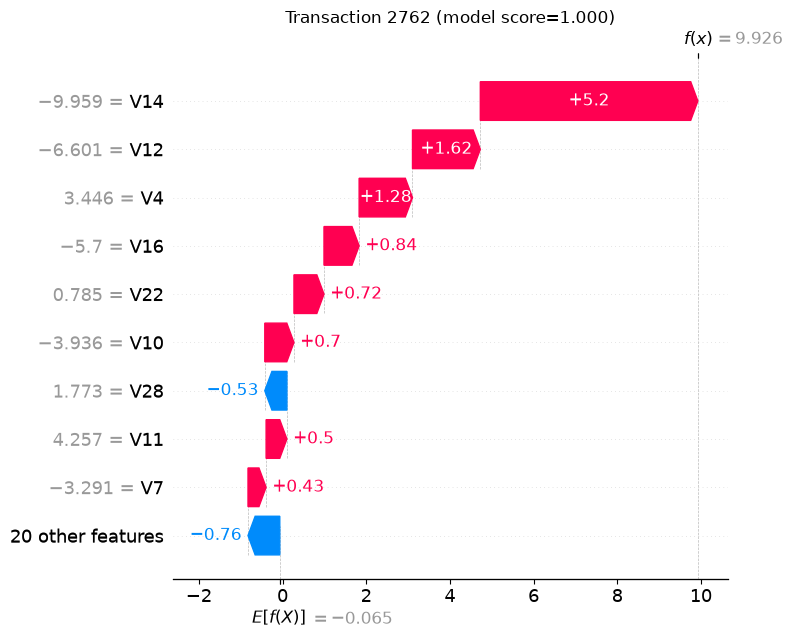

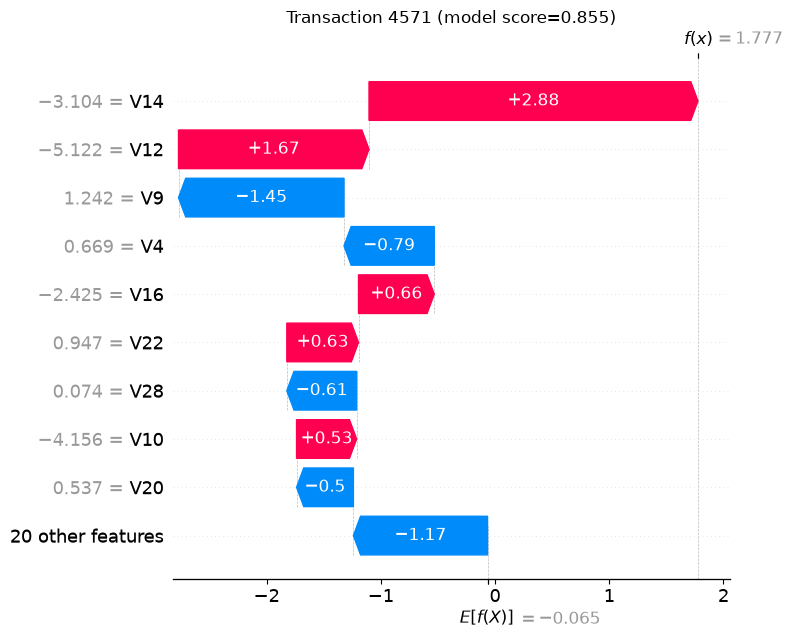

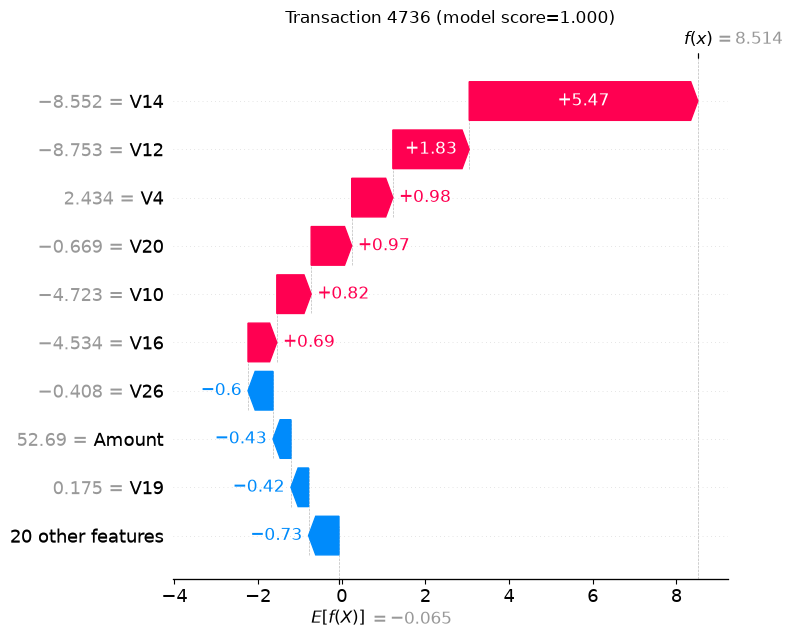

In [6]:
import shap

for i in range(len(example_idx)):
    shap.plots.waterfall(explanation[i], show=False)
    plt.title(f'Transaction {example_idx[i]} (model score={test_df.loc[example_idx[i], "score"]:.3f})')
    plt.tight_layout()
    plt.show()

### Plain-language explanations

- **Transaction 2762 (score 1.000, extremely confident):** flagged almost entirely because of an unusually extreme `V14` value (-9.96, contributing +5.20 to the fraud score) and `V12` (-6.60, +1.62). These are by far the two largest contributions — the model is essentially saying "this transaction's V14/V12 combination looks nothing like a normal transaction."
- **Transaction 4571 (score 0.855, still flagged but less extreme):** `V14` (-3.10) is again the top driver (+2.88), with `V12` (-5.12, +1.67) reinforcing it — but `V9` (+1.24) actually pushed *against* fraud (-1.45), which is why this transaction is less confidently flagged than the other two. This shows the model isn't just checking one feature — it's weighing conflicting evidence.
- **Transaction 4736 (score 1.000):** same pattern — `V14` (-8.55, +5.47) and `V12` (-8.75, +1.83) dominate again.

**Consistent with Phase 1:** `V14` and `V12` were 2 of the 4 features we found most correlated with `Class` in the EDA notebook. Seeing them dominate individual SHAP explanations too is a good consistency check — the global pattern and the per-transaction reasoning agree, rather than SHAP surfacing some feature the earlier analysis never flagged.